# 02 Correlation Analysis — Data Guide

ก่อน run analysis ขอ map ว่าแต่ละ dataset ที่เราเลือกมา **ตอบคำถามอะไร** และ **ทำไมต้องใช้ตัวนี้**

---

## 9 ปัจจัยที่ขับเคลื่อนเศรษฐกิจ

| # | ปัจจัย | Dataset ที่ใช้ | Frequency |
|---|---|---|---|
| 1 | **Consumption** — คนกล้าใช้เงินไหม | `consumption_pct_gdp`, `th_property_prices`, `us_consumer_sentiment` | Annual / Quarterly / Monthly |
| 2 | **Interest Rate** — ดอกเบี้ยแพงแค่ไหน | `lending_rate`, `us_10yr_treasury`, `us_fed_funds_rate`, `policy_rate_monthly` | Annual / Daily / Monthly |
| 3 | **Inflation** — ของแพงแค่ไหน | `inflation`, `us_cpi_monthly`, `cpi_monthly` | Annual / Monthly |
| 4 | **Unemployment** — คนตกงานเยอะไหม | `unemployment`, `us_unemployment` | Annual / Monthly |
| 5 | **Business Investment** — บริษัทกล้าลงทุนไหม | `gross_capital_formation`, `us_industrial_prod` | Annual / Monthly |
| 6 | **Trade & Exports** — โลกซื้อของไทยไหม | `exports_pct_gdp`, `imports_pct_gdp`, `USD_THB`, `th_exchange_rate_real`, `th_us_imports`, `oil` | Mixed |
| 7 | **Geopolitical Risk** — นักลงทุนกลัวแค่ไหน | `vix`, `gold`, `th_uncertainty`, `global_uncertainty`, `news_sentiment` | Daily / Quarterly / Monthly |
| 8 | **Technology** — sector เทคโนโลยีโต/หด | `nasdaq`, `us_industrial_prod`, `gdp_growth` | Daily / Monthly / Annual |
| 9 | **Government Policy** — รัฐกระตุ้นหรือรัดเข็มขัด | `govt_expenditure`, `govt_debt`, `us_fed_funds_rate` | Annual / Monthly |

---

## ทำไมถึงใช้ข้อมูล US/Global แทน Thailand รายเดือน?

> ไทยส่งออกประมาณ **70% of GDP** — เมื่อ US/Global economy เปลี่ยน ไทยรู้สึกภายใน **1-3 เดือน**

FRED (Federal Reserve) มี Thailand data เฉพาะรายปีเป็นส่วนใหญ่ แต่ US/Global indicators รายเดือนมีครบและ reliable:

| FRED Series | ชื่อ | ทำไมสำคัญกับไทย |
|---|---|---|
| `FEDFUNDS` | US Federal Funds Rate | เมื่อ Fed ขึ้นดอกเบี้ย → เงินทุนไหลออกจาก emerging markets รวมถึงไทย |
| `CPIAUCSL` | US CPI (Inflation) | US inflation สูง → Fed ขึ้นดอกเบี้ย → กดดันเงินบาท |
| `UNRATE` | US Unemployment | US คนตกงานเยอะ → ซื้อของจากไทยน้อยลง → ส่งออกไทยลด |
| `INDPRO` | US Industrial Production | proxy ความต้องการสินค้าจากโรงงานไทย |
| `GEPUCURRENT` | Global Policy Uncertainty | ความไม่แน่นอนโลก → นักลงทุนถอนเงินออกจากไทย |
| `UMCSENT` | US Consumer Sentiment | คนอเมริกันมั่นใจ → ซื้อของมากขึ้น → ดีกับส่งออกไทย |

---

## Thailand-specific จาก FRED

| FRED Series | ชื่อ | Factor |
|---|---|---|
| `RBTHBIS` | Real Effective Exchange Rate | factor 6: ค่าเงินบาทเทียบตะกร้าสกุลเงิน |
| `IMP5490` | US Imports from Thailand | factor 6: วัดความต้องการสินค้าไทยจาก US |
| `QTHR628BIS` | Bangkok Property Prices | factor 1: proxy การบริโภค / ความมั่งคั่ง |
| `WUITHA` | World Uncertainty Index TH | factor 7: ความไม่แน่นอนเฉพาะในไทย |

---

## Market Signals จาก yfinance (รายวัน)

| Ticker | ชื่อ | Factor | Logic |
|---|---|---|---|
| `^SET.BK` | SET Index | target | ตลาดหุ้นไทย — mirror ของ sentiment เศรษฐกิจ |
| `THB=X` | USD/THB | 6 | ค่าบาทแข็ง → ส่งออกแพงขึ้น → กระทบ competitiveness |
| `^VIX` | VIX Fear Index | 7 | VIX > 30 = ตลาดกลัวมาก → เงินไหลออก EM |
| `GC=F` | Gold | 7 | ทองขึ้นเมื่อคนกลัว → inverse กับ risk appetite |
| `^GSPC` | S&P 500 | 6, 8 | global risk appetite — ถ้า S&P ลง EM มักลงด้วย |
| `CL=F` | Crude Oil | 6 | ไทยนำเข้าน้ำมัน — น้ำมันแพง → ต้นทุนสูง → inflation |
| `^TNX` | US 10-yr Treasury | 2 | yield สูง → ดึงเงินจาก EM → บาทอ่อน |
| `^IXIC` | Nasdaq | 8 | tech sector — indicator ของ innovation cycle โลก |

---

## ข้อควรระวังก่อน interpret ผล

1. **Frequency ต่างกัน** — macro รายปีกับ market รายวันเปรียบตรงๆ ไม่ได้ ต้อง aggregate ก่อน
2. **Correlation ≠ Causation** — ตัวเลขสูงไม่แปลว่า X ทำให้เกิด Y
3. **Granger causality** บอกได้แค่ว่า X มีข้อมูลช่วยทำนาย Y — ไม่ใช่เหตุผลจริง
4. **Macro data น้อย** — World Bank ให้แค่ ~25 ปี → statistical power ต่ำ ต้องระวังการ overfit
5. **IMF data** — tail ที่เห็นอาจเป็น forecast ไม่ใช่ historical → filter `year <= 2025` แล้ว


# 02 Correlation Analysis

วิเคราะห์ความสัมพันธ์ระหว่างตัวแปรทั้งหมด:
- Pearson correlation
- Lagged correlation (ตัวแปรไหนนำ/ตาม)
- Granger causality
- Rolling correlation

In [15]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import grangercausalitytests

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 50)

RAW_DIR = Path('../../data/raw')

In [ ]:
def read_market(name):
    df = pd.read_csv(RAW_DIR / f'{name}_market_signals.csv')
    df['date'] = pd.to_datetime(df['date'])
    df['close'] = pd.to_numeric(df['close'], errors='coerce')
    return df.set_index('date')[['close']].rename(columns={'close': name})

def read_macro(filename, col_name):
    df = pd.read_csv(RAW_DIR / filename)
    df['year'] = pd.to_numeric(df['year'], errors='coerce')
    df['value'] = pd.to_numeric(df['value'], errors='coerce')
    return df.set_index('year')[['value']].rename(columns={'value': col_name})

def read_fred(name):
    """Load a FRED monthly series: date, value, series → DatetimeIndex with col=name"""
    df = pd.read_csv(RAW_DIR / f'fred_{name}.csv')
    df['date'] = pd.to_datetime(df['date'])
    df['value'] = pd.to_numeric(df['value'], errors='coerce')
    return df.set_index('date')[['value']].rename(columns={'value': name})

# --- Market signals (daily) — covers factors 2,6,7,8 ---
market = pd.concat([
    read_market('SET_index'),
    read_market('USD_THB'),
    read_market('gold'),
    read_market('oil'),
    read_market('sp500'),
    read_market('vix'),
    read_market('us_10yr_treasury'),  # factor 2: interest rate benchmark
    read_market('nasdaq'),            # factor 8: technology
], axis=1).sort_index()

returns = market.pct_change().dropna()

# --- Macro annual (World Bank / IMF) — historical <=2025 ---
macro = pd.concat([
    read_macro('consumption_pct_gdp_TH.csv',     'consumption'),       # factor 1
    read_macro('lending_rate_TH.csv',             'lending_rate'),      # factor 2
    read_macro('inflation_TH.csv',                'inflation'),          # factor 3
    read_macro('thailand_unemployment_rate.csv',  'unemployment'),       # factor 4
    read_macro('gross_capital_formation_TH.csv',  'business_invest'),   # factor 5
    read_macro('exports_pct_gdp_TH.csv',          'exports_pct_gdp'),   # factor 6
    read_macro('imports_pct_gdp_TH.csv',          'imports_pct_gdp'),   # factor 6
    read_macro('imf_gdp_growth_TH.csv',           'gdp_growth'),         # factor 8 proxy
    read_macro('govt_expenditure_pct_gdp_TH.csv', 'govt_expenditure'),  # factor 9
    read_macro('govt_debt_pct_gdp_TH.csv',        'govt_debt'),          # factor 9
], axis=1).sort_index()
macro = macro[macro.index <= 2025]

# --- FRED monthly (high-frequency proxies) ---
fred_monthly = pd.concat([
    read_fred('th_exchange_rate_real'),   # factor 6: trade competitiveness
    read_fred('th_us_imports'),           # factor 6: US demand for Thai goods
    read_fred('th_property_prices'),      # factor 1: domestic consumption signal
    read_fred('th_uncertainty'),          # factor 7: geopolitical risk
    read_fred('us_fed_funds_rate'),       # factor 2: global interest rate anchor
    read_fred('us_cpi_monthly'),          # factor 3: global inflation signal
    read_fred('us_unemployment'),         # factor 4: global demand proxy
    read_fred('us_industrial_prod'),      # factor 5: global investment cycle
    read_fred('global_uncertainty'),      # factor 7: EPU index
    read_fred('us_consumer_sentiment'),   # factor 1/8: consumer confidence
    read_fred('us_govt_spending'),        # factor 9: US fiscal stance
], axis=1).sort_index()

# Resample FRED to monthly end-of-month to align for correlation
fred_monthly = fred_monthly.resample('ME').last()
fred_returns = fred_monthly.pct_change().dropna(how='all')

# News sentiment monthly (factor 7: confidence proxy)
news = pd.read_csv(RAW_DIR / 'news_sentiment.csv')
news['published_dt'] = pd.to_datetime(news['published'], errors='coerce')
news['month'] = news['published_dt'].dt.to_period('M').dt.to_timestamp()
news_monthly = news.groupby('month')['compound'].mean().rename('sentiment_score')

print(f"market      : {market.shape}  cols={list(market.columns)}")
print(f"returns     : {returns.shape}")
print(f"macro       : {macro.shape}")
print(f"fred_monthly: {fred_monthly.shape}  cols={list(fred_monthly.columns)}")
print(f"\nmacro tail (historical):")
print(macro.dropna(how='all').tail(6))
print(f"\nfred_monthly tail:")
print(fred_monthly.dropna(how='all').tail(3))


## 1. Pearson Correlation — Daily Returns

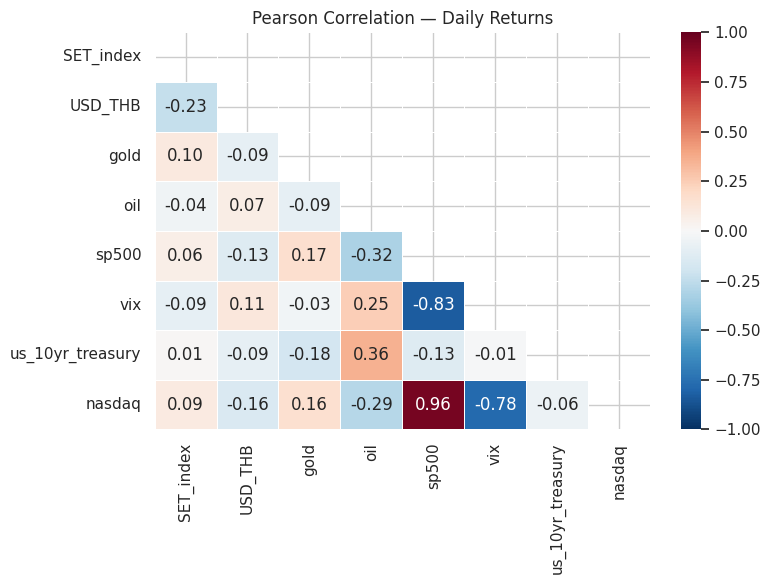

Top 5 correlated pairs:
         asset_a asset_b      corr
          nasdaq   sp500  0.959218
             vix   sp500 -0.831499
          nasdaq     vix -0.778910
us_10yr_treasury     oil  0.358555
           sp500     oil -0.318341


In [17]:
corr = returns.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(8, 6))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5, vmin=-1, vmax=1)
plt.title('Pearson Correlation — Daily Returns')
plt.tight_layout()
plt.show()

pairs = (
    corr.where(~mask).stack()
    .reset_index()
    .rename(columns={'level_0': 'asset_a', 'level_1': 'asset_b', 0: 'corr'})
    .sort_values('corr', key=abs, ascending=False)
)
print('Top 5 correlated pairs:')
print(pairs.head(5).to_string(index=False))

## 2. Lagged Correlation — ตัวแปรไหนนำ / ตาม

lag < 0 → X นำหน้า Y (leading indicator) | lag > 0 → X ตามหลัง Y

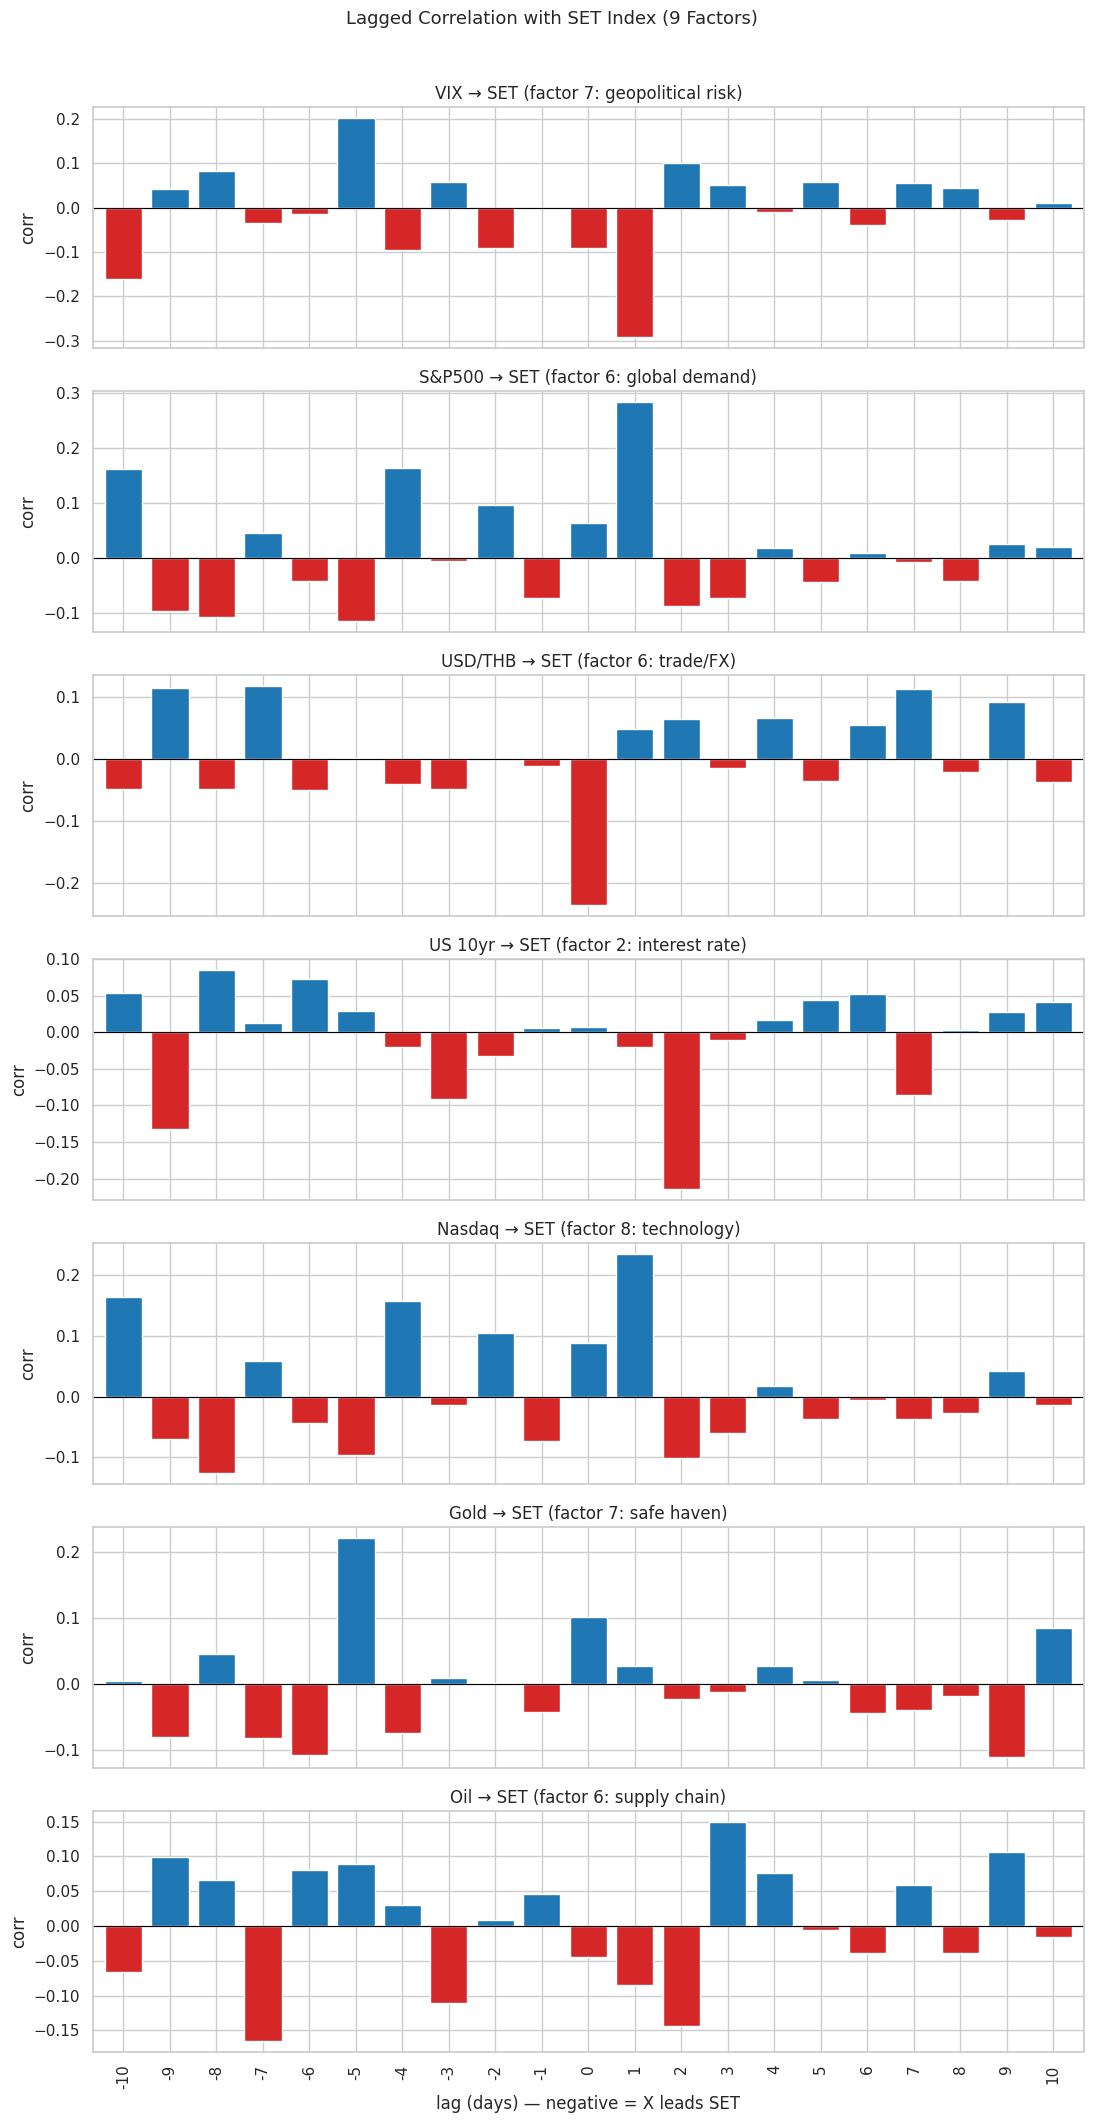

In [18]:
def lagged_corr(x, y, max_lag=10):
    lags = range(-max_lag, max_lag + 1)
    return pd.Series([x.corr(y.shift(-lag)) for lag in lags], index=lags)

lag_pairs = [
    ('vix',              'SET_index', 'VIX → SET (factor 7: geopolitical risk)'),
    ('sp500',            'SET_index', 'S&P500 → SET (factor 6: global demand)'),
    ('USD_THB',          'SET_index', 'USD/THB → SET (factor 6: trade/FX)'),
    ('us_10yr_treasury', 'SET_index', 'US 10yr → SET (factor 2: interest rate)'),
    ('nasdaq',           'SET_index', 'Nasdaq → SET (factor 8: technology)'),
    ('gold',             'SET_index', 'Gold → SET (factor 7: safe haven)'),
    ('oil',              'SET_index', 'Oil → SET (factor 6: supply chain)'),
]

fig, axes = plt.subplots(len(lag_pairs), 1, figsize=(11, 3 * len(lag_pairs)), sharex=True)

for ax, (x_col, y_col, label) in zip(axes, lag_pairs):
    lc = lagged_corr(returns[x_col], returns[y_col])
    lc.plot(kind='bar', ax=ax, color=['tab:red' if v < 0 else 'tab:blue' for v in lc], width=0.8)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title(label)
    ax.set_ylabel('corr')

axes[-1].set_xlabel('lag (days) — negative = X leads SET')
plt.suptitle('Lagged Correlation with SET Index (9 Factors)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


## 3. Granger Causality

**p < 0.05** = X ช่วยทำนาย Y ได้มากกว่าใช้ประวัติ Y อย่างเดียว → candidate feature สำหรับ model

Granger Causality — does X help predict SET Index?
       predictor                      factor  min_pvalue significant
             vix factor 7: geopolitical/fear      0.0000       ✅ yes
           sp500     factor 6: global demand      0.0000       ✅ yes
          nasdaq        factor 8: technology      0.0003       ✅ yes
us_10yr_treasury     factor 2: interest rate      0.0069       ✅ yes
             oil      factor 6: supply chain      0.0166       ✅ yes
            gold        factor 7: safe haven      0.5760        ❌ no
         USD_THB          factor 6: trade/FX      0.7205        ❌ no


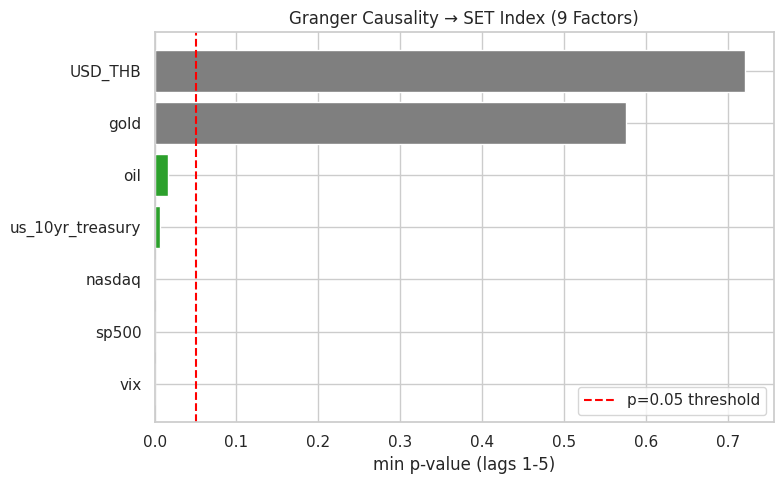

In [19]:
def granger_pvalue(x, y, max_lag=5):
    data = pd.concat([y, x], axis=1).dropna()
    try:
        res = grangercausalitytests(data, maxlag=max_lag, verbose=False)
        return min(res[lag][0]['ssr_ftest'][1] for lag in range(1, max_lag + 1))
    except Exception:
        return np.nan

target = 'SET_index'
predictors = {
    'vix':              'factor 7: geopolitical/fear',
    'sp500':            'factor 6: global demand',
    'USD_THB':          'factor 6: trade/FX',
    'us_10yr_treasury': 'factor 2: interest rate',
    'nasdaq':           'factor 8: technology',
    'gold':             'factor 7: safe haven',
    'oil':              'factor 6: supply chain',
}

results = pd.DataFrame([{
    'predictor': p,
    'factor':    label,
    'min_pvalue': round(granger_pvalue(returns[p], returns[target]), 4),
} for p, label in predictors.items()])
results['significant'] = results['min_pvalue'].apply(lambda v: '✅ yes' if v < 0.05 else '❌ no')
results = results.sort_values('min_pvalue')

print('Granger Causality — does X help predict SET Index?')
print(results.to_string(index=False))

plt.figure(figsize=(8, 5))
colors = ['tab:green' if p < 0.05 else 'tab:gray' for p in results['min_pvalue']]
plt.barh(results['predictor'], results['min_pvalue'], color=colors)
plt.axvline(0.05, color='red', linestyle='--', label='p=0.05 threshold')
plt.xlabel('min p-value (lags 1-5)')
plt.title('Granger Causality → SET Index (9 Factors)')
plt.legend()
plt.tight_layout()
plt.show()


## 4. Macro Correlation — Annual Indicators

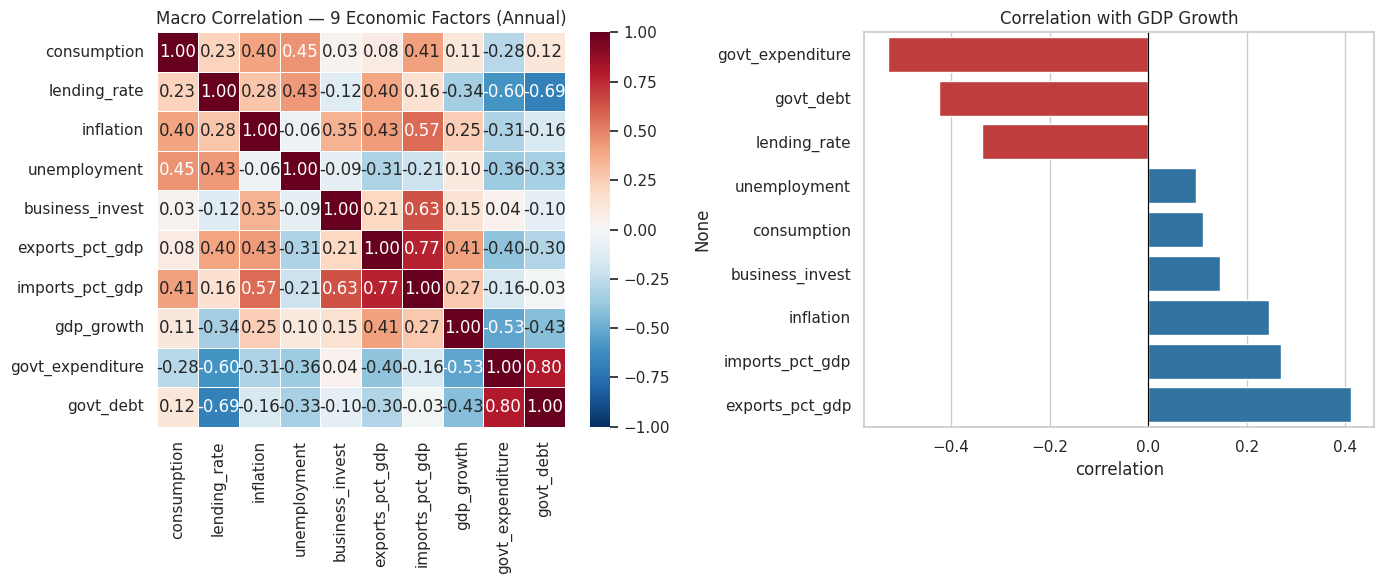


Macro tail:
      consumption  lending_rate  inflation  unemployment  business_invest  \
year                                                                        
2018    48.888513      4.146667   1.063898         0.765        25.219590   
2019    49.773808      4.084167   0.706729         0.716        23.814753   
2020    53.047600      3.292500  -0.845937         1.099        23.755385   
2021    52.239681      3.060000   1.230395         1.215        28.669036   
2022    54.564965      3.138333  -1.610680         0.940        27.858429   
2023    57.481430      4.285833   8.478052         0.733        22.460510   
2024    58.210625      4.514167   1.365805         0.781        21.580929   
2025          NaN           NaN        NaN         0.781              NaN   

      exports_pct_gdp  imports_pct_gdp  gdp_growth  govt_expenditure  \
year                                                                   
2018        64.838097        56.003768         4.2         19.019694   


In [20]:
macro_clean = macro.dropna(how='all')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Full heatmap
sns.heatmap(macro_clean.corr(), annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5, vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title('Macro Correlation — 9 Economic Factors (Annual)')

# Correlation with GDP growth (target)
gdp_corr = macro_clean.corr()[['gdp_growth']].drop('gdp_growth').sort_values('gdp_growth')
sns.barplot(x='gdp_growth', y=gdp_corr.index, data=gdp_corr.reset_index(),
            palette=['tab:red' if v < 0 else 'tab:blue' for v in gdp_corr['gdp_growth']],
            ax=axes[1])
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Correlation with GDP Growth')
axes[1].set_xlabel('correlation')

plt.tight_layout()
plt.show()

print('\nMacro tail:')
print(macro_clean.tail(8))


## 5. Rolling Correlation — ความสัมพันธ์เปลี่ยนตามเวลา

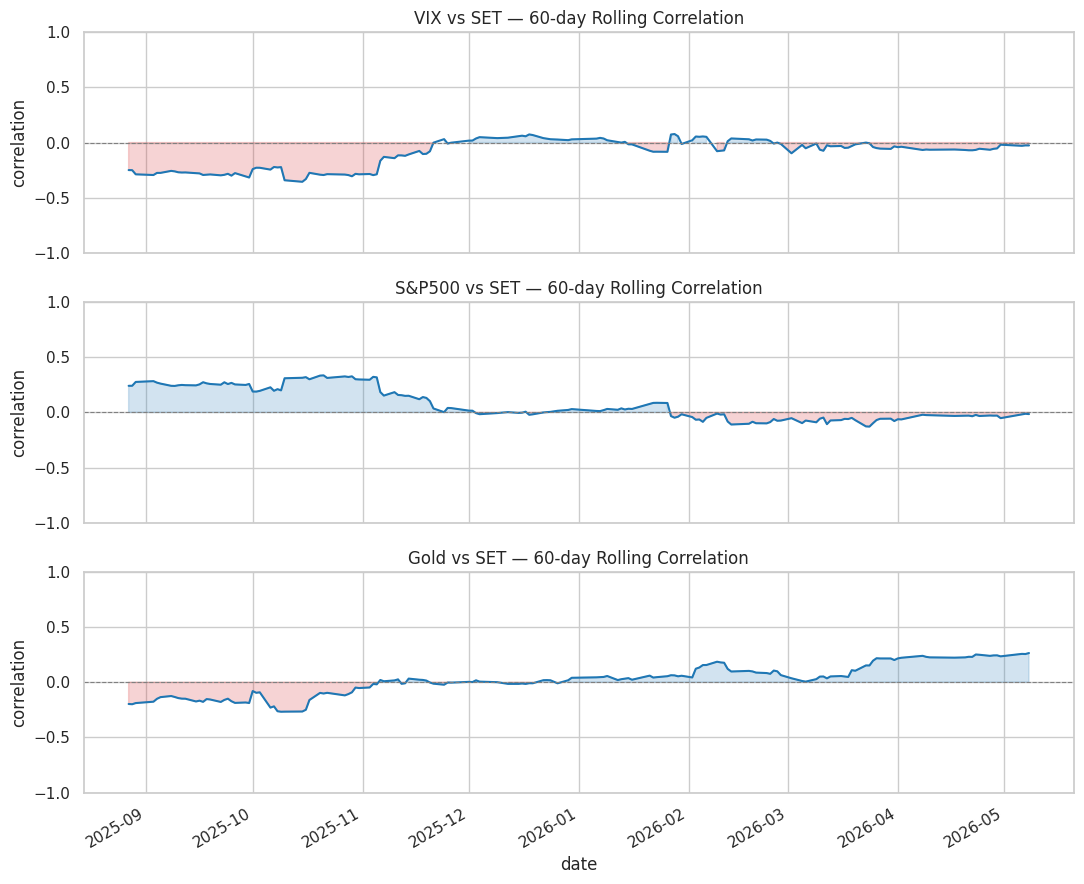

In [21]:
window = 60
rolling_pairs = [
    ('vix',   'SET_index', 'VIX vs SET'),
    ('sp500', 'SET_index', 'S&P500 vs SET'),
    ('gold',  'SET_index', 'Gold vs SET'),
]

fig, axes = plt.subplots(len(rolling_pairs), 1, figsize=(11, 3 * len(rolling_pairs)), sharex=True)

for ax, (a, b, label) in zip(axes, rolling_pairs):
    rc = returns[a].rolling(window).corr(returns[b])
    rc.plot(ax=ax, linewidth=1.5, color='tab:blue')
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    ax.fill_between(rc.index, rc, 0, where=(rc >= 0), alpha=0.2, color='tab:blue')
    ax.fill_between(rc.index, rc, 0, where=(rc < 0),  alpha=0.2, color='tab:red')
    ax.set_title(f'{label} — {window}-day Rolling Correlation')
    ax.set_ylabel('correlation')
    ax.set_ylim(-1, 1)

plt.tight_layout()
plt.show()

## 6. FRED Monthly — High-Frequency Factor Correlations

Annual World Bank data tells us **what happened** over years. FRED monthly data tells us **what's happening now**.

Here we:
- Correlate monthly % changes in FRED indicators against each other (structure of global forces)
- Align FRED monthly data with SET monthly returns to see leading/lagging signals

> **Why monthly changes?** Level data (e.g. CPI = 300) has spurious correlation due to shared trends. % change (MoM) removes trend and shows genuine co-movement.

In [ ]:
# --- FRED inter-indicator correlation heatmap ---
fred_corr = fred_returns.corr()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Left: heatmap of FRED indicator relationships
mask_u = np.triu(np.ones_like(fred_corr, dtype=bool))
sns.heatmap(
    fred_corr, mask=mask_u, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, ax=axes[0],
    linewidths=0.3, square=True,
    annot_kws={'size': 7}
)
axes[0].set_title('FRED Monthly Indicator Correlations (MoM %)', fontsize=11)
axes[0].tick_params(axis='x', rotation=45, labelsize=8)
axes[0].tick_params(axis='y', rotation=0, labelsize=8)

# Right: FRED vs SET Index monthly returns
# Align SET (daily) to monthly end-of-month
set_monthly = market[['SET_index']].resample('ME').last().pct_change().dropna()
set_monthly.columns = ['SET_index_monthly']

combined = fred_returns.join(set_monthly, how='inner').dropna(how='all')

if 'SET_index_monthly' in combined.columns and len(combined) > 5:
    corr_vs_set = combined.corr()['SET_index_monthly'].drop('SET_index_monthly').sort_values()
    colors = ['tab:red' if v < 0 else 'tab:green' for v in corr_vs_set]
    corr_vs_set.plot(kind='barh', ax=axes[1], color=colors)
    axes[1].axvline(0, color='black', linewidth=0.8)
    axes[1].set_title('FRED Monthly Indicators vs SET Index (monthly return correlation)', fontsize=11)
    axes[1].set_xlabel('Pearson r')
    for bar, val in zip(axes[1].patches, corr_vs_set):
        axes[1].text(
            val + (0.005 if val >= 0 else -0.005),
            bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center',
            ha='left' if val >= 0 else 'right', fontsize=8
        )
else:
    axes[1].text(0.5, 0.5, 'Not enough overlapping months', ha='center', va='center')

plt.tight_layout()
plt.show()

# Print top correlated FRED pairs
pairs = (
    fred_corr.where(~mask_u)
    .stack()
    .reset_index()
    .rename(columns={'level_0':'A','level_1':'B',0:'r'})
    .assign(abs_r=lambda d: d['r'].abs())
    .sort_values('abs_r', ascending=False)
)
print('Top 10 FRED indicator pairs by absolute correlation:')
print(pairs.head(10)[['A','B','r']].to_string(index=False))


## Summary

| คำถาม | วิธี | Section |
|---|---|---|
| ตัวแปรไหน relate กันบ้าง? | Pearson heatmap | 1 |
| ตัวแปรไหนนำ/ตามกัน? | Lagged correlation | 2 |
| X ทำนาย Y ได้จริงไหม? | Granger causality | 3 |
| Macro relate กันยังไง? | Annual correlation | 4 |
| ความสัมพันธ์เปลี่ยนตามเวลาไหม? | Rolling 60d | 5 |

**ตัวที่ Granger p < 0.05 → นำไปเป็น features ใน `03_model_forecast.ipynb`**